In [15]:
import numpy as np
import glob
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


In [19]:
import matplotlib as mpl

mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
mpl.rcParams['axes.labelsize'] = 16  # Anche per le etichette degli assi
mpl.rcParams['axes.titlesize'] = 18  # Anche per il titolo

# Ora tutti i grafici seguiranno queste impostazioni


Elaborazione per Aeff-0...


C:\Users\Asus\AppData\Local\Temp\ipykernel_25228\381404053.py:76: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integrale_energia, _ = spi.quad(integranda, E_new.min(), E_new.max(), limit=200)


Elaborazione per Aeff-10...
Elaborazione per Aeff-20...
Elaborazione per Aeff-30...
Elaborazione per Aeff-40...


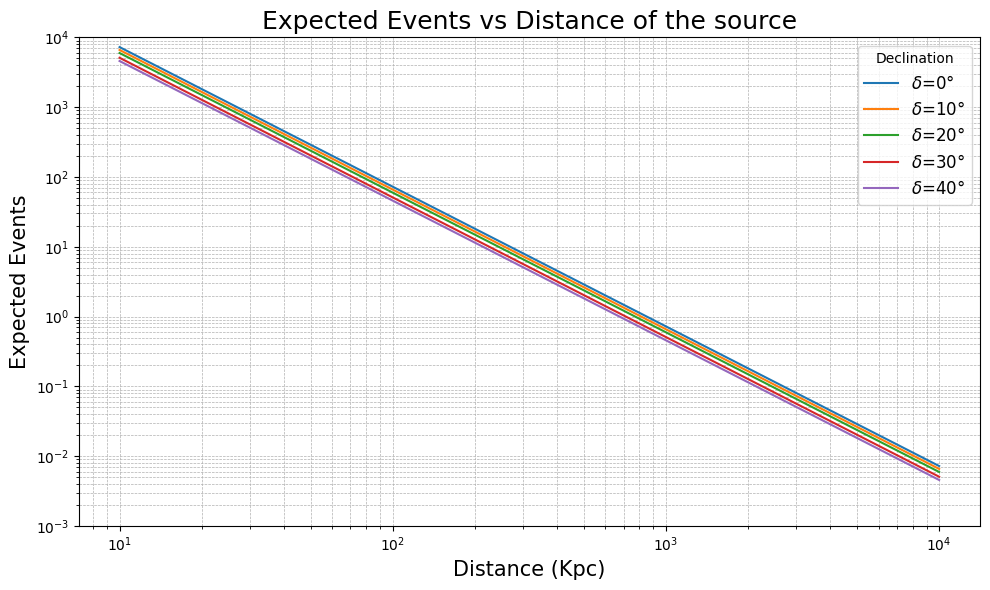

In [1]:
import glob
import numpy as np
import scipy.integrate as spi
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# Ottenere la lista di tutti i file .dat nella cartella SN_IIn
file_list = glob.glob('SN_IIn/SNIIn_20_block_*.dat')

# Vettore lightcurve e tempo per IIP S=2.0
time_all_P = []
flux_all_P = []
block_ranges = [(1, 51)]

# Lista per i risultati finali
Num_event_all_aeff = []

# Ciclo per tutte le aree efficaci (da aeff-10 a aeff-90)
for i in range(0, 50, 10):
    # Caricamento dell'area efficace (Aeff)
    aeff_data = np.genfromtxt(f'Aeff/aeff_{i}.txt', skip_header=1, delimiter=None)
    En = pow(10, aeff_data[:, 0])  # Conversione da log10(E) a E
    Aeff = aeff_data[:, 1]
    
    # Creazione della funzione di interpolazione per l'area efficace
    interpolation_function = interp1d(En, Aeff, kind='linear', fill_value="extrapolate")
    
    # Calcolo eventi per l'area efficace corrente
    Num_event = 0.0  # Reset per ogni aeff
    Num_tot = []     # Numero totale per ogni blocco
    n_ev = []        # Eventi attesi per ciascuna distanza

    print(f"Elaborazione per Aeff-{i}...")

    # Itera su ogni intervallo di blocchi
    for idx, (start_block, end_block) in enumerate(block_ranges, start=1):
        for file_name in file_list:
            # Estrai il numero di blocco dal nome del file
            block_number = int(file_name.split('SNIIn_20_block_')[-1].split('.')[0])
            
            # Controlla se il blocco rientra nel range corrente
            if start_block <= block_number <= end_block:
                # Calcola S_IIn basato sul numero di blocco
                S_IIn_start = 1e5 * pow(10., 0.1 * (block_number - 1))
                S_IIn_stop = 1e5 * pow(10., 0.1 * (block_number))

                delta_t = S_IIn_stop - S_IIn_start
                
                if S_IIn_start > 1e8:
                    print(f"Blocco {block_number} ignorato: S_n_start = {S_IIn_start} > 10^8") 
                    continue

                # Carica i dati dal file .dat
                new_data = np.loadtxt(file_name)
                
                if new_data[-1, -1] == 1:
                    Ev_all = new_data[:, 0]
                    Ev = Ev_all[Ev_all > 3e8]/1e9
                    dN_dEv = new_data[:, 7][Ev_all > 3e8]
                    dN_dEv = dN_dEv * (1 / 6*1e9)  
                    
                    lunghezza_Ev = len(Ev)
                    time = np.linspace(S_IIn_start, 1e8, lunghezza_Ev)

                    interpolation_flux = interp1d(Ev, dN_dEv, kind='cubic', fill_value="extrapolate")
                    E_new = np.linspace(Ev.min(), Ev.max(), 500)
                    flux_new = interpolation_flux(E_new)

                    # Definizione dell'integranda
                    def integranda(e):
                        flux = interpolation_flux(e) 
                        aeff = interpolation_function(e)  # Usa l'area effettiva corrente
                        return flux * aeff
                    
                    # Calcola l'integrale dell'energia
                    integrale_energia, _ = spi.quad(integranda, E_new.min(), E_new.max(), limit=200)

                    N_k = integrale_energia * delta_t  # Ponderazione per l'istante temporale t_start_k
                    
                    # Aggiorna il numero totale di eventi attesi
                    Num_event += N_k
                    Num_tot.append(N_k)
                    
                    time_all_P.append(block_number) 

    # Calcolo del numero di eventi attesi per ogni distanza
    d_min = 10 * 3.086e19  # 10 Kpc in metri
    d_max = 10 * 3.086e22  # 10 Mpc in metri
    d_values = np.logspace(np.log10(d_min), np.log10(d_max), 100)  

    n_ev_per_aeff = []
    for d in d_values:
        geom_con = 1 / (4 * np.pi * d ** 2)
        expected_events = Num_event * geom_con
        n_ev_per_aeff.append(expected_events)
    
    # Salva i risultati per l'area effettiva corrente
    Num_event_all_aeff.append({
        "aeff": f"$\delta$={i}°",
        "num_event": Num_event,
        "num_tot": Num_tot,
        "n_ev": n_ev_per_aeff,
        "d_values": d_values
    })

# Plot degli eventi attesi in funzione della distanza
plt.figure(figsize=(10, 6))

for result in Num_event_all_aeff:
    d_values = result["d_values"]
    n_ev = result["n_ev"]
    aeff_label = result["aeff"]
    
    plt.plot(d_values / 3.086e19, n_ev, label=aeff_label)  # Converti distanza in Mpc

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Distance (Kpc)', fontsize=15)
plt.ylabel('Expected Events', fontsize=15)
plt.title('Expected Events vs Distance of the source', fontsize=18)
plt.legend(title="Declination", fontsize=12)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.ylim(1e-3,1e4)
plt.show()


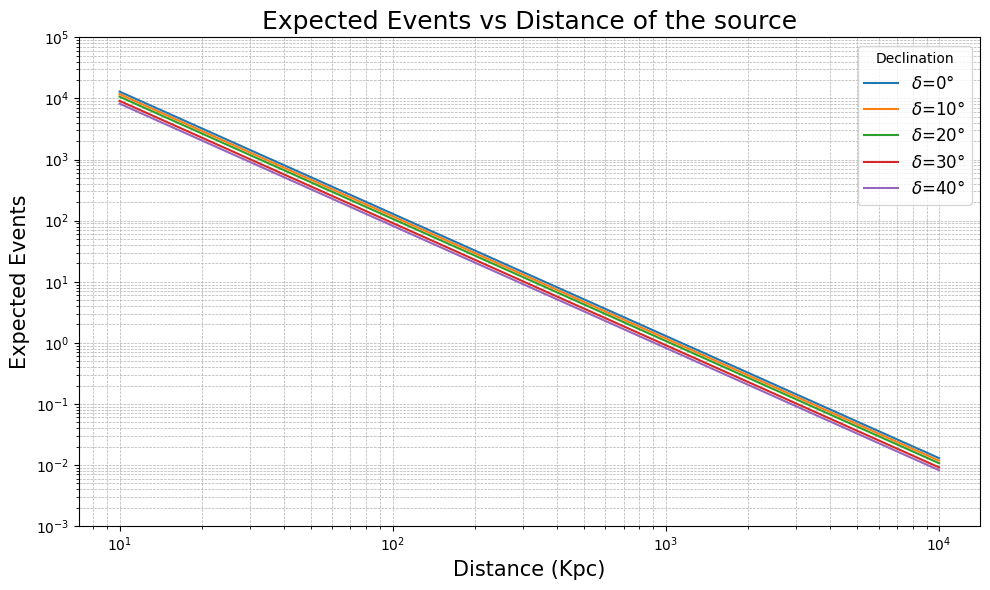

In [6]:
# Plot degli eventi attesi in funzione della distanza
plt.figure(figsize=(10, 6))

for result in Num_event_all_aeff:
    d_values = result["d_values"]
    n_ev = result["n_ev"]
    aeff_label = result["aeff"]
    
    plt.plot(d_values / 3.086e19, n_ev, label=aeff_label)  # Converti distanza in Mpc

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Distance (Kpc)', fontsize=15)
plt.ylabel('Expected Events', fontsize=15)
plt.title('Expected Events vs Distance of the source', fontsize=18)
plt.legend(title="Declination", fontsize=12)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.ylim(1e-3,1e5)
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_10140\248291769.py:26: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(Aeff.min(), 4e3)


AttributeError: module 'matplotlib.pyplot' has no attribute 'set_yticks'

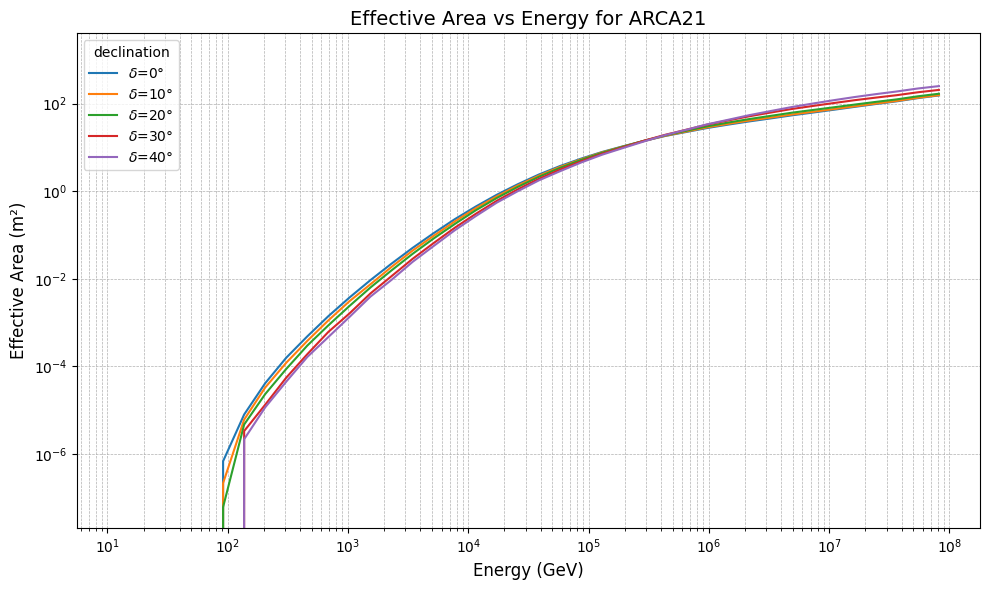

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Figura per il plot di Aeff vs En
plt.figure(figsize=(10, 6))

# Ciclo su tutte le aree efficaci (da aeff-10 a aeff-90)
for i in range(0, 50, 10):
    # Caricamento dell'area efficace (Aeff)
    aeff_data = np.genfromtxt(f'Aeff/aeff_{i}.txt', skip_header=1, delimiter=None)
    En_log = aeff_data[:, 0]  # log10(E)
    En = 10**En_log          # Conversione da log10(E) a E
    Aeff = aeff_data[:, 3]
    
    # Plotta l'area efficace in funzione dell'energia
    plt.plot(En, Aeff, label=f"$\delta$={i}°")
    
ytick=np.arange(1e-8,1e3,1e1)
# Dettagli del grafico
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy (GeV)', fontsize=12)
plt.ylabel('Effective Area (m²)', fontsize=12)
plt.title('Effective Area vs Energy for ARCA21', fontsize=14)
plt.legend(title="declination")
plt.ylim(Aeff.min(), 4e3)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()

# Mostra il grafico
plt.show()


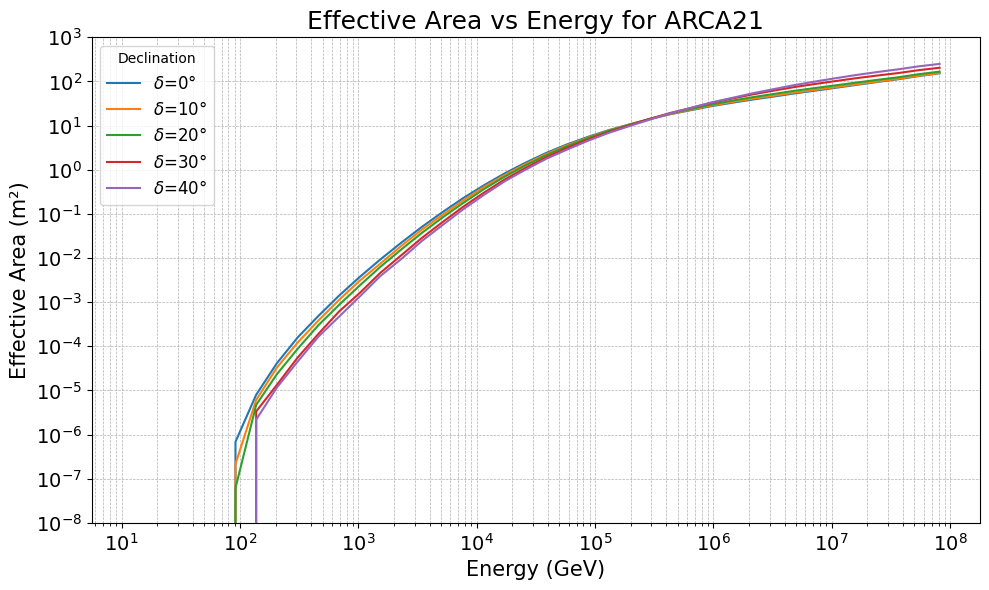

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Figura per il plot di Aeff vs En
fig, ax = plt.subplots(figsize=(10, 6))  # Creazione dell'oggetto Axes

# Ciclo su tutte le aree efficaci (da aeff-10 a aeff-90)
for i in range(0, 50, 10):
    # Caricamento dell'area efficace (Aeff)
    aeff_data = np.genfromtxt(f'Aeff/aeff_{i}.txt', skip_header=1, delimiter=None)
    En_log = aeff_data[:, 0]  # log10(E)
    En = 10**En_log          # Conversione da log10(E) a E
    Aeff = aeff_data[:, 3]
    
    # Plotta l'area efficace in funzione dell'energia
    ax.plot(En, Aeff, label=f"$\delta$={i}°")

# Ticks personalizzati sull'asse Y
ytick = np.logspace(-8, 3, num=12)  # Genera tick logaritmici tra 1e-8 e 1e3

# Dettagli del grafico
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Energy (GeV)', fontsize=15)
ax.set_ylabel('Effective Area (m²)', fontsize=15)
ax.set_title('Effective Area vs Energy for ARCA21', fontsize=18)
ax.legend(title="Declination", fontsize=12)
#ax.set_ylim(Aeff.min(), 4e3)
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

# Imposta i ticks personalizzati
ax.set_yticks(ytick)


# Layout e visualizzazione
fig.tight_layout()
plt.show()


Elaborazione per Aeff-0...


C:\Users\Asus\AppData\Local\Temp\ipykernel_1896\983616863.py:76: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integrale_energia, _ = spi.quad(integranda, E_new.min(), E_new.max(), limit=200)


Elaborazione per Aeff-10...
Elaborazione per Aeff-20...
Elaborazione per Aeff-30...
Elaborazione per Aeff-40...


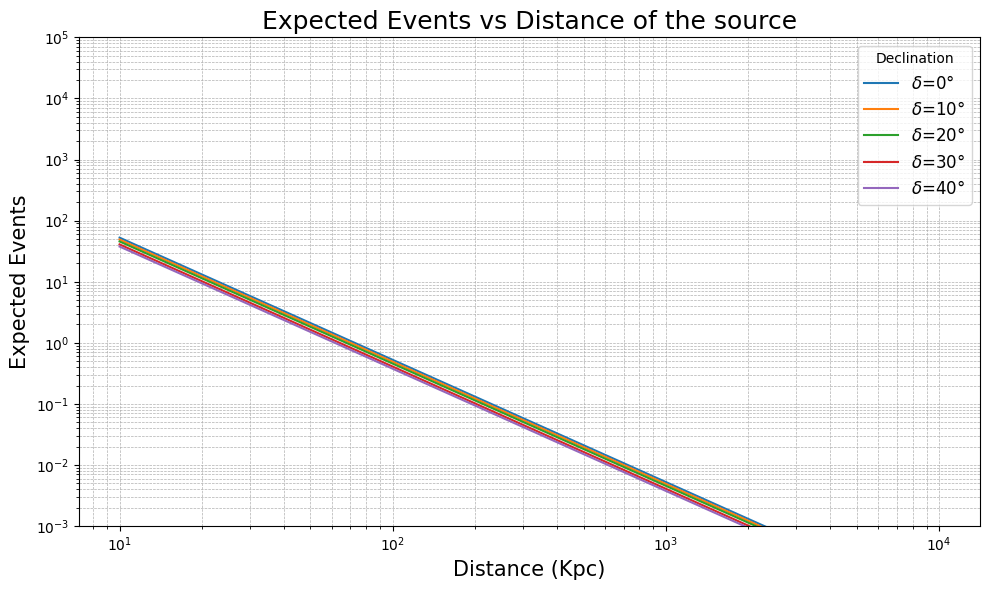

In [8]:
import glob
import numpy as np
import scipy.integrate as spi
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# Ottenere la lista di tutti i file .dat nella cartella SN_IIn
file_list = glob.glob('SN_IIP/SNIIP_20_block_*.dat')

# Vettore lightcurve e tempo per IIP S=2.0
time_all_P = []
flux_all_P = []
block_ranges = [(1, 51)]

# Lista per i risultati finali
Num_event_all_aeff = []

# Ciclo per tutte le aree efficaci (da aeff-10 a aeff-90)
for i in range(0, 50, 10):
    # Caricamento dell'area efficace (Aeff)
    aeff_data = np.genfromtxt(f'Aeff/aeff_{i}.txt', skip_header=1, delimiter=None)
    En = pow(10, aeff_data[:, 0])  # Conversione da log10(E) a E
    Aeff = aeff_data[:, 3]
    
    # Creazione della funzione di interpolazione per l'area efficace
    interpolation_function = interp1d(En, Aeff, kind='linear', fill_value="extrapolate")
    
    # Calcolo eventi per l'area efficace corrente
    Num_event = 0.0  # Reset per ogni aeff
    Num_tot = []     # Numero totale per ogni blocco
    n_ev = []        # Eventi attesi per ciascuna distanza

    print(f"Elaborazione per Aeff-{i}...")

    # Itera su ogni intervallo di blocchi
    for idx, (start_block, end_block) in enumerate(block_ranges, start=1):
        for file_name in file_list:
            # Estrai il numero di blocco dal nome del file
            block_number = int(file_name.split('SNIIP_20_block_')[-1].split('.')[0])
            
            # Controlla se il blocco rientra nel range corrente
            if start_block <= block_number <= end_block:
                # Calcola S_IIn basato sul numero di blocco
                S_IIp_start = 1e3 * pow(10., 0.1 * (block_number - 1))
                S_IIp_stop = 1e3 * pow(10., 0.1 * (block_number))

                delta_t = S_IIp_stop - S_IIp_start
                
                if S_IIp_start > 1e8:
                    print(f"Blocco {block_number} ignorato: S_n_start = {S_IIn_start} > 10^8") 
                    continue

                # Carica i dati dal file .dat
                new_data = np.loadtxt(file_name)
                
                if new_data[-1, -1] == 1:
                    Ev_all = new_data[:, 0]
                    Ev = Ev_all[Ev_all > 3e8]/1e9
                    dN_dEv = new_data[:, 7][Ev_all > 3e8]
                    dN_dEv = dN_dEv * (1 / 3*1e9)  
                    
                    lunghezza_Ev = len(Ev)
                    

                    interpolation_flux = interp1d(Ev, dN_dEv, kind='linear', fill_value="extrapolate")
                    E_new = np.linspace(Ev.min(), Ev.max(), 500)
                    flux_new = interpolation_flux(E_new)

                    # Definizione dell'integranda
                    def integranda(e):
                        flux = interpolation_flux(e) 
                        aeff = interpolation_function(e)  # Usa l'area effettiva corrente
                        return flux * aeff
                    
                    # Calcola l'integrale dell'energia
                    integrale_energia, _ = spi.quad(integranda, E_new.min(), E_new.max(), limit=200)

                    N_k = integrale_energia * delta_t  # Ponderazione per l'istante temporale t_start_k
                    
                    # Aggiorna il numero totale di eventi attesi
                    Num_event += N_k
                    Num_tot.append(N_k)
                    
                    time_all_P.append(block_number) 

    # Calcolo del numero di eventi attesi per ogni distanza
    d_min = 10 * 3.086e19  # 10 pc in metri
    d_max = 10 * 3.086e22  # 10 Mpc in metri
    d_values = np.logspace(np.log10(d_min), np.log10(d_max), 100)  

    n_ev_per_aeff = []
    for d in d_values:
        geom_con = 1 / (4 * np.pi * d ** 2)
        expected_events = Num_event * geom_con
        n_ev_per_aeff.append(expected_events)
    
    # Salva i risultati per l'area effettiva corrente
    Num_event_all_aeff.append({
        "aeff": f"$\delta$={i}°",
        "num_event": Num_event,
        "num_tot": Num_tot,
        "n_ev": n_ev_per_aeff,
        "d_values": d_values
    })

# Plot degli eventi attesi in funzione della distanza
plt.figure(figsize=(10, 6))

for result in Num_event_all_aeff:
    d_values = result["d_values"]
    n_ev = result["n_ev"]
    aeff_label = result["aeff"]
    
    plt.plot(d_values / 3.086e19, n_ev, label=aeff_label)  # Converti distanza in Mpc

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Distance (Kpc)', fontsize=15)
plt.ylabel('Expected Events', fontsize=15)
plt.title('Expected Events vs Distance of the source', fontsize=18)
plt.legend(title="Declination", fontsize=12)
plt.ylim(1e-3,1e5)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()
